# Stage 1 sweep analysis

This notebook analyzes the merged Stage 1 summary file.

It focuses on:

- fitness statistics,
- weighted ecological consistency statistics,
- algorithm shares,
- parameter effects,
- correlation between fitness, ecological consistency and ARI,
- top-N analysis by ecological consistency,
- comparison between top-N by ecological consistency and top-N by fitness,
- histograms for fitness and ecological consistency.

Change `TOP_N` below to analyze a different number of best configurations.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import pearsonr, spearmanr
except Exception:
    pearsonr = None
    spearmanr = None

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

SUMMARY_PATH = Path(r"../experiments/results/stage1_sweep_summary.csv")

# Change this value whenever you want a different elite subset.
TOP_N = 100

# Column names from the summary file.
FITNESS_COL = "mean_best_fitness"
ECO_COL = "mean_weighted_combined_ecological_consistency"
ARI_COL = "mean_ari_vs_kmeans"

# Number of bins for histograms.
N_BINS = 20

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


## 1. Load data

In [2]:
def read_csv_auto(path):
    """Read comma- or semicolon-separated CSV automatically."""
    df = pd.read_csv(path)
    if df.shape[1] == 1:
        df = pd.read_csv(path, sep=";")
    return df


df = read_csv_auto(SUMMARY_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())
print(df.columns.tolist())


Rows: 252
Columns: 33


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec
0,aco_centroid_refinement,all_ants,0.75,1.0,0.10,0.05,koppen,superpixels,0.263341,0.002081,0.261870,0.263341,0.002081,0.261870,0.216794,0.002520,0.371951,0.001056,0.621056,0.051318,0.484622,0.000080,0.484679,0.478287,0.004598,0.415723,0.000421,0.484771,0.001545,0.037950,0.000002,68.871459,0.118269
1,aco_centroid_refinement,all_ants,0.75,1.0,0.02,0.05,koppen,superpixels,0.272919,0.013057,0.263687,0.272919,0.013057,0.263687,0.223604,0.008292,0.387988,0.024176,0.653641,0.052739,0.483537,0.001922,0.484896,0.476331,0.003561,0.417349,0.000035,0.483558,0.000027,0.037983,0.000009,68.823792,0.049095
2,aco_centroid,all_ants,1.00,3.0,0.10,0.05,koppen,superpixels,0.245458,0.002000,0.244044,0.245458,0.002000,0.244044,0.205646,0.002933,0.338352,0.000176,0.646103,0.103762,0.483457,0.008653,0.489575,0.463893,0.005197,0.412817,0.012995,0.487659,0.002353,0.037986,0.000015,27.819972,0.031742
3,aco_centroid_refinement,all_ants,0.75,3.0,0.02,0.05,koppen,superpixels,0.242617,0.001467,0.241580,0.242617,0.001467,0.241580,0.200508,0.001963,0.340872,0.000308,0.761585,0.000575,0.482643,0.003482,0.485105,0.482036,0.001282,0.419511,0.003528,0.488088,0.000329,0.037947,0.000006,69.078657,0.011801
4,aco_centroid_refinement,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.242757,0.001832,0.241461,0.242757,0.001832,0.241461,0.200788,0.002127,0.340686,0.001144,0.761235,0.002144,0.482539,0.003980,0.485353,0.481707,0.001885,0.418778,0.002937,0.488269,0.001178,0.037946,0.000012,69.122594,0.105857


['algorithm', 'pheromone_update', 'alpha', 'beta', 'evaporation', 'q', 'feature_mode', 'mode', 'mean_best_fitness', 'std_best_fitness', 'best_best_fitness', 'mean_recomputed_fitness', 'std_recomputed_fitness', 'best_recomputed_fitness', 'mean_compactness', 'std_compactness', 'mean_spatial', 'std_spatial', 'mean_ari_vs_kmeans', 'std_ari_vs_kmeans', 'mean_weighted_combined_ecological_consistency', 'std_weighted_combined_ecological_consistency', 'best_weighted_combined_ecological_consistency', 'mean_mean_combined_ecological_consistency', 'std_mean_combined_ecological_consistency', 'mean_weighted_agriculture_homogeneity', 'std_weighted_agriculture_homogeneity', 'mean_weighted_natural_homogeneity', 'std_weighted_natural_homogeneity', 'mean_weighted_artificial_share_total', 'std_weighted_artificial_share_total', 'mean_runtime_sec', 'std_runtime_sec']


## 2. Basic checks

In [3]:
required_cols = [
    "algorithm",
    "pheromone_update",
    "alpha",
    "beta",
    "evaporation",
    "q",
    FITNESS_COL,
    ECO_COL,
    ARI_COL,
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep only rows where main metrics exist.
df = df.dropna(subset=[FITNESS_COL, ECO_COL, ARI_COL]).copy()

# Make sure parameter columns are numeric where possible.
for col in ["alpha", "beta", "evaporation", "q"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Rows after dropping missing main metrics:", len(df))
print("Algorithms:", sorted(df["algorithm"].unique()))
print("Pheromone updates:", sorted(df["pheromone_update"].unique()))


Rows after dropping missing main metrics: 252
Algorithms: ['aco_centroid', 'aco_centroid_refinement', 'aco_cohesion', 'aco_cohesion_refinement', 'aco_graph_local', 'multi_centroid_graph_spatial', 'multi_cohesion_graph_spatial']
Pheromone updates: ['all_ants', 'best_ant', 'quality_weighted']


## 3. Helper functions

In [4]:
def describe_metric(data, col):
    return pd.Series({
        "count": data[col].count(),
        "min": data[col].min(),
        "mean": data[col].mean(),
        "median": data[col].median(),
        "max": data[col].max(),
        "std": data[col].std(),
        "range": data[col].max() - data[col].min(),
    })


def count_share(data, col):
    out = data[col].value_counts(dropna=False).rename("count").reset_index()
    out.columns = [col, "count"]
    out["share"] = out["count"] / out["count"].sum()
    return out


def parameter_summary(data, param_col):
    return (
        data
        .groupby(param_col, dropna=False)
        .agg(
            count=(param_col, "size"),
            mean_fitness=(FITNESS_COL, "mean"),
            std_fitness=(FITNESS_COL, "std"),
            mean_ecological_consistency=(ECO_COL, "mean"),
            std_ecological_consistency=(ECO_COL, "std"),
            mean_ari=(ARI_COL, "mean"),
            std_ari=(ARI_COL, "std"),
        )
        .reset_index()
        .sort_values(param_col)
    )


def algorithm_summary(data):
    return (
        data
        .groupby("algorithm", dropna=False)
        .agg(
            count=("algorithm", "size"),
            mean_fitness=(FITNESS_COL, "mean"),
            std_fitness=(FITNESS_COL, "std"),
            mean_ecological_consistency=(ECO_COL, "mean"),
            std_ecological_consistency=(ECO_COL, "std"),
            mean_ari=(ARI_COL, "mean"),
            std_ari=(ARI_COL, "std"),
            mean_runtime_sec=("mean_runtime_sec", "mean") if "mean_runtime_sec" in data.columns else (FITNESS_COL, "size"),
        )
        .reset_index()
        .sort_values("mean_ecological_consistency", ascending=False)
    )


def correlations(data, cols=None):
    if cols is None:
        cols = [FITNESS_COL, ECO_COL, ARI_COL]

    rows = []
    pairs = [
        (FITNESS_COL, ECO_COL),
        (FITNESS_COL, ARI_COL),
        (ECO_COL, ARI_COL),
    ]

    for x, y in pairs:
        work = data[[x, y]].dropna()

        pearson = work[x].corr(work[y], method="pearson")
        spearman = work[x].corr(work[y], method="spearman")

        rows.append({
            "x": x,
            "y": y,
            "n": len(work),
            "pearson": pearson,
            "spearman": spearman,
        })

    return pd.DataFrame(rows)


def top_by_ecology(data, n):
    return data.sort_values(ECO_COL, ascending=False).head(n).copy()


def top_by_fitness(data, n):
    return data.sort_values(FITNESS_COL, ascending=True).head(n).copy()


def config_id_frame(data):
    cols = ["algorithm", "pheromone_update", "alpha", "beta", "evaporation", "q"]
    return data[cols].astype(str).agg("|".join, axis=1)


def compare_top_sets(data, n):
    top_eco = top_by_ecology(data, n)
    top_fit = top_by_fitness(data, n)

    eco_ids = set(config_id_frame(top_eco))
    fit_ids = set(config_id_frame(top_fit))

    overlap = eco_ids & fit_ids

    return {
        "top_n": n,
        "eco_count": len(eco_ids),
        "fitness_count": len(fit_ids),
        "overlap_count": len(overlap),
        "overlap_share_of_top_n": len(overlap) / n,
        "only_ecology_count": len(eco_ids - fit_ids),
        "only_fitness_count": len(fit_ids - eco_ids),
        "top_ecology": top_eco,
        "top_fitness": top_fit,
        "overlap_ids": overlap,
    }


def plot_hist(data, col, title, bins=N_BINS):
    plt.figure(figsize=(8, 5))
    plt.hist(data[col].dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Number of configurations")
    plt.tight_layout()
    plt.show()


def plot_hist_by_group(data, col, group_col, bins=N_BINS):
    groups = list(data[group_col].dropna().unique())
    for group in groups:
        subset = data[data[group_col] == group]
        plt.figure(figsize=(8, 5))
        plt.hist(subset[col].dropna(), bins=bins)
        plt.title(f"{col} distribution — {group_col} = {group}")
        plt.xlabel(col)
        plt.ylabel("Number of configurations")
        plt.tight_layout()
        plt.show()


def plot_box_by_group(data, col, group_col, title=None):
    groups = list(data[group_col].dropna().unique())
    values = [data.loc[data[group_col] == g, col].dropna().to_numpy() for g in groups]

    plt.figure(figsize=(max(8, len(groups) * 1.3), 5))
    plt.boxplot(values, labels=groups, vert=True)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(col)
    plt.title(title or f"{col} by {group_col}")
    plt.tight_layout()
    plt.show()


def scatter_plot(data, x, y, group_col=None, title=None):
    plt.figure(figsize=(8, 6))

    if group_col is None:
        plt.scatter(data[x], data[y], alpha=0.8)
    else:
        for group, subset in data.groupby(group_col):
            plt.scatter(subset[x], subset[y], alpha=0.8, label=str(group))
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()


In [8]:
best_by_fitness = top_by_fitness(df, 1)
best_by_eco_consistency = top_by_ecology(df, 1)
# print(best_by_fitness)
# aco_centroid         best_ant    1.0   3.0          0.1  0.05       koppen  superpixels
# print(best_by_eco_consistency)
# aco_centroid_refinement         all_ants   0.75   1.0          0.1  0.05       koppen  superpixels

                 algorithm pheromone_update  alpha  beta  evaporation     q feature_mode         mode  mean_best_fitness  std_best_fitness  best_best_fitness  \
0  aco_centroid_refinement         all_ants   0.75   1.0          0.1  0.05       koppen  superpixels           0.263341          0.002081            0.26187   

   mean_recomputed_fitness  std_recomputed_fitness  best_recomputed_fitness  mean_compactness  std_compactness  mean_spatial  std_spatial  mean_ari_vs_kmeans  std_ari_vs_kmeans  \
0                 0.263341                0.002081                  0.26187          0.216794          0.00252      0.371951     0.001056            0.621056           0.051318   

   mean_weighted_combined_ecological_consistency  std_weighted_combined_ecological_consistency  best_weighted_combined_ecological_consistency  \
0                                       0.484622                                       0.00008                                       0.484679   

   mean_mean_combined_eco

## 4. Overall statistics

In [9]:
overall_stats = pd.DataFrame({
    "fitness": describe_metric(df, FITNESS_COL),
    "weighted_ecological_consistency": describe_metric(df, ECO_COL),
    "ari_vs_kmeans": describe_metric(df, ARI_COL),
}).T

display(overall_stats)


,count,min,mean,median,max,std,range
fitness,252.0,0.232473,0.461342,0.351385,0.930701,0.239116,0.698228
weighted_ecological_consistency,252.0,0.394593,0.444793,0.452702,0.484622,0.026368,0.090029
ari_vs_kmeans,252.0,0.003411,0.390972,0.445800,0.761585,0.214716,0.758174


In [13]:
df.columns

Index(['algorithm', 'pheromone_update', 'alpha', 'beta', 'evaporation', 'q', 'feature_mode', 'mode', 'mean_best_fitness', 'std_best_fitness', 'best_best_fitness',
       'mean_recomputed_fitness', 'std_recomputed_fitness', 'best_recomputed_fitness', 'mean_compactness', 'std_compactness', 'mean_spatial', 'std_spatial', 'mean_ari_vs_kmeans',
       'std_ari_vs_kmeans', 'mean_weighted_combined_ecological_consistency', 'std_weighted_combined_ecological_consistency', 'best_weighted_combined_ecological_consistency',
       'mean_mean_combined_ecological_consistency', 'std_mean_combined_ecological_consistency', 'mean_weighted_agriculture_homogeneity', 'std_weighted_agriculture_homogeneity',
       'mean_weighted_natural_homogeneity', 'std_weighted_natural_homogeneity', 'mean_weighted_artificial_share_total', 'std_weighted_artificial_share_total', 'mean_runtime_sec',
       'std_runtime_sec'],
      dtype='object')

## 5. Overall algorithm and parameter summaries

In [14]:
print("Algorithm summary")
display(algorithm_summary(df))

print("Parameter summary: alpha")
display(parameter_summary(df, "alpha"))

print("Parameter summary: beta")
display(parameter_summary(df, "beta"))

print("Parameter summary: evaporation")
display(parameter_summary(df, "evaporation"))

print("Parameter summary: pheromone_update")
display(parameter_summary(df, "pheromone_update"))


Algorithm summary


,algorithm,count,mean_fitness,std_fitness,mean_ecological_consistency,std_ecological_consistency,mean_ari,std_ari,mean_runtime_sec
0,aco_centroid,36,0.270062,0.039708,0.470007,0.005512,0.597232,0.058831,28.214600
1,aco_centroid_refinement,36,0.314050,0.102681,0.468340,0.013039,0.581945,0.129538,69.027155
5,multi_centroid_graph_spatial,36,0.357732,0.096786,0.453501,0.009749,0.450030,0.078960,39.655219
4,aco_graph_local,36,0.520096,0.195001,0.434433,0.016052,0.311288,0.133905,52.246226
6,multi_cohesion_graph_spatial,36,0.564302,0.227286,0.431368,0.020675,0.271901,0.172897,54.817428
3,aco_cohesion_refinement,36,0.598525,0.304569,0.429412,0.032248,0.271577,0.254540,215.769774
2,aco_cohesion,36,0.604628,0.283170,0.426492,0.027923,0.252831,0.226428,72.809010


Parameter summary: alpha


,alpha,count,mean_fitness,std_fitness,mean_ecological_consistency,std_ecological_consistency,mean_ari,std_ari
0,0.75,84,0.485372,0.252442,0.442796,0.027714,0.374653,0.226834
1,1.00,84,0.441534,0.230390,0.446730,0.025772,0.414086,0.211297
2,2.00,84,0.457120,0.234737,0.444854,0.025738,0.384177,0.206064


Parameter summary: beta


,beta,count,mean_fitness,std_fitness,mean_ecological_consistency,std_ecological_consistency,mean_ari,std_ari
0,1.0,126,0.627259,0.237668,0.430073,0.029076,0.263605,0.225531
1,3.0,126,0.295424,0.053167,0.459513,0.010670,0.518339,0.094900


Parameter summary: evaporation


,evaporation,count,mean_fitness,std_fitness,mean_ecological_consistency,std_ecological_consistency,mean_ari,std_ari
0,0.02,126,0.463777,0.240962,0.444621,0.02647,0.388964,0.215448
1,0.10,126,0.458907,0.238193,0.444965,0.02637,0.392981,0.214823


Parameter summary: pheromone_update


,pheromone_update,count,mean_fitness,std_fitness,mean_ecological_consistency,std_ecological_consistency,mean_ari,std_ari
0,all_ants,84,0.442370,0.238705,0.447032,0.027983,0.412277,0.225048
1,best_ant,84,0.476728,0.239728,0.443430,0.025729,0.375904,0.208509
2,quality_weighted,84,0.464928,0.240502,0.443917,0.025491,0.384735,0.211113


## 6. Overall correlations

In [ ]:
display(correlations(df))

print("Correlations within each algorithm family")
family_corrs = []
for alg, subset in df.groupby("algorithm"):
    corr = correlations(subset)
    corr.insert(0, "algorithm", alg)
    family_corrs.append(corr)

family_corrs = pd.concat(family_corrs, ignore_index=True)
display(family_corrs)


## 7. Histograms: all configurations

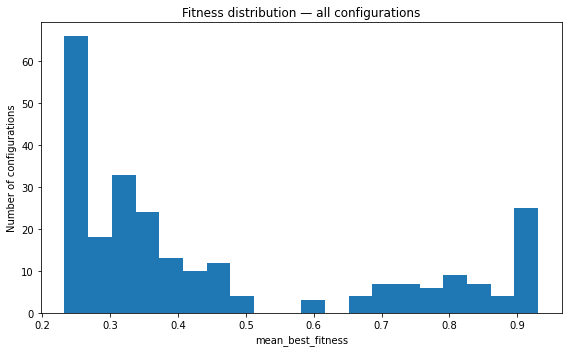

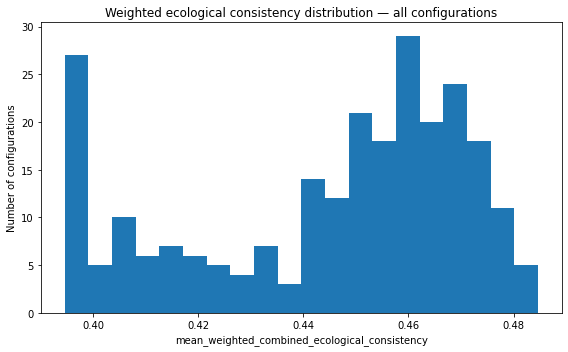

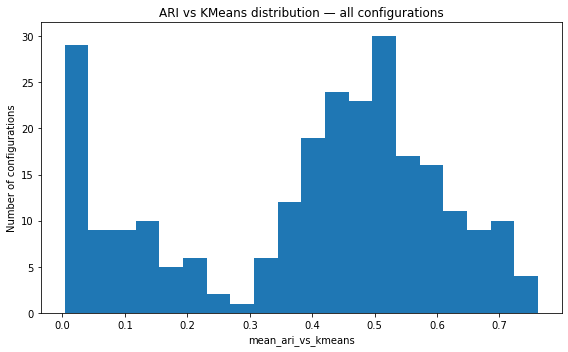

In [11]:
plot_hist(df, FITNESS_COL, "Fitness distribution — all configurations", bins=N_BINS)
plot_hist(df, ECO_COL, "Weighted ecological consistency distribution — all configurations", bins=N_BINS)
plot_hist(df, ARI_COL, "ARI vs KMeans distribution — all configurations", bins=N_BINS)


## 8. Histograms and boxplots by algorithm

In [ ]:
plot_hist_by_group(df, FITNESS_COL, "algorithm", bins=N_BINS)
plot_hist_by_group(df, ECO_COL, "algorithm", bins=N_BINS)


## 9. Histograms and boxplots by parameter values

In [ ]:
for param in ["alpha", "beta", "evaporation", "pheromone_update"]:
    print(f"===== {param} =====")
    plot_box_by_group(df, FITNESS_COL, param, f"Fitness by {param}")
    plot_box_by_group(df, ECO_COL, param, f"Weighted ecological consistency by {param}")
    plot_box_by_group(df, ARI_COL, param, f"ARI vs KMeans by {param}")


## 10. Scatter plots

In [ ]:
scatter_plot(
    df,
    FITNESS_COL,
    ECO_COL,
    group_col="algorithm",
    title="Ecological consistency vs fitness by algorithm",
)

scatter_plot(
    df,
    FITNESS_COL,
    ARI_COL,
    group_col="algorithm",
    title="ARI vs fitness by algorithm",
)

scatter_plot(
    df,
    ARI_COL,
    ECO_COL,
    group_col="algorithm",
    title="Ecological consistency vs ARI by algorithm",
)


## 11. Top-N by weighted ecological consistency

In [21]:
TOP_N = 25
top_eco = top_by_ecology(df, TOP_N)

print(f"Top {TOP_N} configurations by weighted ecological consistency")
display(top_eco)

top_eco_stats = pd.DataFrame({
    "fitness": describe_metric(top_eco, FITNESS_COL),
    "weighted_ecological_consistency": describe_metric(top_eco, ECO_COL),
    "ari_vs_kmeans": describe_metric(top_eco, ARI_COL),
}).T

display(top_eco_stats)

print("Algorithm composition")
display(count_share(top_eco, "algorithm"))

print("Alpha composition")
display(count_share(top_eco, "alpha"))

print("Beta composition")
display(count_share(top_eco, "beta"))

print("Evaporation composition")
display(count_share(top_eco, "evaporation"))

print("Pheromone update composition")
display(count_share(top_eco, "pheromone_update"))

print("Q composition")
display(count_share(top_eco, "q"))

print("Correlations inside top ecological subset")
display(correlations(top_eco))


Top 25 configurations by weighted ecological consistency


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec
0,aco_centroid_refinement,all_ants,0.75,1.0,0.10,0.05,koppen,superpixels,0.263341,0.002081,0.261870,0.263341,0.002081,0.261870,0.216794,0.002520,0.371951,0.001056,0.621056,0.051318,0.484622,0.000080,0.484679,0.478287,0.004598,0.415723,0.000421,0.484771,0.001545,0.037950,0.000002,68.871459,0.118269
1,aco_centroid_refinement,all_ants,0.75,1.0,0.02,0.05,koppen,superpixels,0.272919,0.013057,0.263687,0.272919,0.013057,0.263687,0.223604,0.008292,0.387988,0.024176,0.653641,0.052739,0.483537,0.001922,0.484896,0.476331,0.003561,0.417349,0.000035,0.483558,0.000027,0.037983,0.000009,68.823792,0.049095
2,aco_centroid,all_ants,1.00,3.0,0.10,0.05,koppen,superpixels,0.245458,0.002000,0.244044,0.245458,0.002000,0.244044,0.205646,0.002933,0.338352,0.000176,0.646103,0.103762,0.483457,0.008653,0.489575,0.463893,0.005197,0.412817,0.012995,0.487659,0.002353,0.037986,0.000015,27.819972,0.031742
3,aco_centroid_refinement,all_ants,0.75,3.0,0.02,0.05,koppen,superpixels,0.242617,0.001467,0.241580,0.242617,0.001467,0.241580,0.200508,0.001963,0.340872,0.000308,0.761585,0.000575,0.482643,0.003482,0.485105,0.482036,0.001282,0.419511,0.003528,0.488088,0.000329,0.037947,0.000006,69.078657,0.011801
4,aco_centroid_refinement,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.242757,0.001832,0.241461,0.242757,0.001832,0.241461,0.200788,0.002127,0.340686,0.001144,0.761235,0.002144,0.482539,0.003980,0.485353,0.481707,0.001885,0.418778,0.002937,0.488269,0.001178,0.037946,0.000012,69.122594,0.105857
5,aco_centroid,all_ants,0.75,1.0,0.02,0.05,koppen,superpixels,0.251291,0.009374,0.244663,0.251291,0.009374,0.244663,0.207239,0.007480,0.354079,0.013793,0.691334,0.043839,0.479994,0.006790,0.484795,0.476764,0.007741,0.412620,0.009093,0.487886,0.001843,0.037980,0.000003,29.114507,0.553432
6,aco_centroid_refinement,all_ants,1.00,1.0,0.02,0.05,koppen,superpixels,0.260267,0.002948,0.258183,0.260267,0.002948,0.258183,0.219356,0.005766,0.355727,0.003630,0.647890,0.008753,0.479431,0.000769,0.479974,0.476603,0.003060,0.409247,0.001308,0.483463,0.003880,0.037973,0.000025,68.742088,0.106246
7,aco_centroid_refinement,all_ants,1.00,3.0,0.02,0.05,koppen,superpixels,0.246528,0.003140,0.244308,0.246528,0.003140,0.244308,0.205882,0.005315,0.341370,0.001936,0.723231,0.012929,0.479262,0.008014,0.484929,0.480066,0.006948,0.413113,0.005411,0.485153,0.004370,0.037952,0.000011,69.147490,0.105724
8,aco_centroid_refinement,all_ants,1.00,3.0,0.10,0.05,koppen,superpixels,0.246790,0.002305,0.245160,0.246790,0.002305,0.245160,0.205928,0.004943,0.342132,0.003850,0.717911,0.019279,0.479213,0.008344,0.485113,0.479769,0.007355,0.413247,0.005850,0.484897,0.003890,0.037958,0.000002,69.152011,0.152141
9,aco_centroid,all_ants,1.00,1.0,0.02,0.05,koppen,superpixels,0.262090,0.021342,0.246999,0.262090,0.021342,0.246999,0.217300,0.010276,0.366600,0.047164,0.622274,0.014351,0.479079,0.012163,0.487679,0.474459,0.008613,0.415568,0.012141,0.483762,0.000178,0.037976,0.000004,28.275751,0.524804


,count,min,mean,median,max,std,range
fitness,25.0,0.232473,0.257776,0.251833,0.310669,0.020012,0.078195
weighted_ecological_consistency,25.0,0.472089,0.477525,0.477298,0.484622,0.003808,0.012533
ari_vs_kmeans,25.0,0.506177,0.659138,0.669082,0.761585,0.067099,0.255408


Algorithm composition


,algorithm,count,share
0,aco_centroid_refinement,13,0.52
1,aco_centroid,12,0.48


...

,pheromone_update,count,share
0,all_ants,19,0.76
1,quality_weighted,5,0.20
2,best_ant,1,0.04


Q composition


,q,count,share
0,0.05,25,1.0


Correlations inside top ecological subset


,x,y,n,pearson,spearman
0,mean_best_fitness,mean_weighted_combined_ecological_consistency,25,-0.192037,0.018462
1,mean_best_fitness,mean_ari_vs_kmeans,25,-0.392377,-0.433077
2,mean_weighted_combined_ecological_consistency,mean_ari_vs_kmeans,25,0.373388,0.314615


## 12. Histograms: Top-N by ecological consistency

In [ ]:
plot_hist(top_eco, FITNESS_COL, f"Fitness distribution — top {TOP_N} by ecology", bins=min(N_BINS, TOP_N))
plot_hist(top_eco, ECO_COL, f"Ecological consistency distribution — top {TOP_N} by ecology", bins=min(N_BINS, TOP_N))
plot_hist(top_eco, ARI_COL, f"ARI distribution — top {TOP_N} by ecology", bins=min(N_BINS, TOP_N))


## 13. Top-N by fitness and overlap with top-N by ecology

In [23]:
top_fit = top_by_fitness(df, TOP_N)

print(f"Top {TOP_N} configurations by fitness")
display(top_fit)

top_fit_stats = pd.DataFrame({
    "fitness": describe_metric(top_fit, FITNESS_COL),
    "weighted_ecological_consistency": describe_metric(top_fit, ECO_COL),
    "ari_vs_kmeans": describe_metric(top_fit, ARI_COL),
}).T

display(top_fit_stats)

print("Algorithm composition")
display(count_share(top_fit, "algorithm"))

print("Alpha composition")
display(count_share(top_fit, "alpha"))

print("Beta composition")
display(count_share(top_fit, "beta"))

print("Evaporation composition")
display(count_share(top_fit, "evaporation"))

print("Pheromone update composition")
display(count_share(top_fit, "pheromone_update"))


print("Correlations inside top fitness subset")
display(correlations(top_fit))


Top 25 configurations by fitness


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec
16,aco_centroid,best_ant,1.00,3.0,0.10,0.05,koppen,superpixels,0.232473,0.000186,0.232342,0.232473,0.000186,0.232342,0.203203,0.005297,0.300772,0.012979,0.543077,0.183277,0.475362,0.007946,0.480981,0.469263,0.020844,0.405760,0.001197,0.486371,0.004845,0.037977,0.000003,27.938951,0.148108
35,aco_centroid,best_ant,1.00,3.0,0.02,0.05,koppen,superpixels,0.233334,0.001479,0.232288,0.233334,0.001479,0.232288,0.201866,0.000237,0.306760,0.004378,0.599285,0.031926,0.470900,0.001350,0.471854,0.458250,0.002295,0.397850,0.005008,0.489746,0.005982,0.037960,0.000010,27.883477,0.018970
39,aco_centroid,best_ant,0.75,3.0,0.02,0.05,koppen,superpixels,0.234111,0.011250,0.226156,0.234111,0.011250,0.226156,0.202889,0.002954,0.306962,0.044392,0.653405,0.190141,0.470616,0.014491,0.480863,0.461914,0.021475,0.400566,0.018202,0.487928,0.002730,0.037976,0.000023,27.831225,0.020630
77,aco_centroid,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.234477,0.004376,0.231383,0.234477,0.004376,0.231383,0.212931,0.002744,0.284750,0.008183,0.521083,0.001862,0.462168,0.005612,0.466136,0.451640,0.009868,0.389715,0.002342,0.487115,0.006031,0.037977,0.000026,27.956953,0.085851
58,aco_centroid,best_ant,2.00,3.0,0.02,0.05,koppen,superpixels,0.235842,0.003110,0.233643,0.235842,0.003110,0.233643,0.212088,0.020512,0.291267,0.058229,0.687786,0.184821,0.466559,0.005703,0.470592,0.437489,0.016822,0.395803,0.015411,0.484805,0.008609,0.037982,0.000005,27.838211,0.004255
43,aco_centroid,all_ants,1.00,3.0,0.02,0.05,koppen,superpixels,0.235957,0.005403,0.232137,0.235957,0.005403,0.232137,0.206753,0.011194,0.304100,0.044128,0.635086,0.183159,0.469679,0.015398,0.480567,0.466337,0.000592,0.396567,0.015321,0.487598,0.000669,0.037981,0.000021,27.887403,0.016390
34,aco_centroid_refinement,best_ant,1.00,3.0,0.02,0.05,koppen,superpixels,0.236014,0.005454,0.232158,0.236014,0.005454,0.232158,0.209614,0.001390,0.297614,0.014937,0.566235,0.029505,0.470922,0.002716,0.472843,0.471001,0.010722,0.399368,0.005251,0.490161,0.001418,0.037980,0.000010,69.049545,0.134816
38,aco_centroid,best_ant,0.75,3.0,0.10,0.05,koppen,superpixels,0.236164,0.001500,0.235104,0.236164,0.001500,0.235104,0.202328,0.002685,0.315113,0.011263,0.653836,0.056557,0.470622,0.002244,0.472209,0.458687,0.003780,0.399775,0.001787,0.484129,0.000786,0.037985,0.000013,27.837242,0.002097
50,aco_centroid,best_ant,2.00,3.0,0.10,0.05,koppen,superpixels,0.236622,0.004185,0.233663,0.236622,0.004185,0.233663,0.212316,0.019552,0.293336,0.059571,0.701638,0.205904,0.468760,0.009024,0.475141,0.435833,0.029156,0.400047,0.018278,0.484839,0.005748,0.037969,0.000016,27.877425,0.042883
33,aco_centroid_refinement,quality_weighted,1.00,3.0,0.02,0.05,koppen,superpixels,0.236862,0.004023,0.234017,0.236862,0.004023,0.234017,0.199059,0.001456,0.325068,0.016807,0.697694,0.157364,0.471294,0.002332,0.472943,0.459690,0.002192,0.404623,0.006972,0.482561,0.004751,0.037960,0.000028,68.973092,0.014250


,count,min,mean,median,max,std,range
fitness,25.0,0.232473,0.239020,0.239001,0.245210,0.003699,0.012737
weighted_ecological_consistency,25.0,0.462168,0.470942,0.470622,0.482643,0.004951,0.020475
ari_vs_kmeans,25.0,0.521083,0.625772,0.614298,0.761585,0.076886,0.240502


Algorithm composition


,algorithm,count,share
0,aco_centroid,14,0.56
1,aco_centroid_refinement,10,0.40
2,aco_cohesion_refinement,1,0.04


...

,evaporation,count,share
0,0.02,13,0.52
1,0.10,12,0.48


Pheromone update composition


,pheromone_update,count,share
0,best_ant,10,0.40
1,quality_weighted,8,0.32
2,all_ants,7,0.28


Correlations inside top fitness subset


,x,y,n,pearson,spearman
0,mean_best_fitness,mean_weighted_combined_ecological_consistency,25,0.151696,0.047692
1,mean_best_fitness,mean_ari_vs_kmeans,25,0.050349,0.060769
2,mean_weighted_combined_ecological_consistency,mean_ari_vs_kmeans,25,0.719755,0.668462


In [22]:
comparison = compare_top_sets(df, TOP_N)

print(f"Top {TOP_N} overlap summary")
display(pd.DataFrame([{
    "top_n": comparison["top_n"],
    "overlap_count": comparison["overlap_count"],
    "overlap_share_of_top_n": comparison["overlap_share_of_top_n"],
    "only_ecology_count": comparison["only_ecology_count"],
    "only_fitness_count": comparison["only_fitness_count"],
}]))

top_fit = comparison["top_fitness"]

print(f"Top {TOP_N} by fitness")
display(top_fit)

print(f"Top {TOP_N} by ecology")
display(comparison["top_ecology"])

# Mark membership.
df_membership = df.copy()
df_membership["_config_id"] = config_id_frame(df_membership)
df_membership["in_top_ecology"] = df_membership["_config_id"].isin(set(config_id_frame(comparison["top_ecology"])))
df_membership["in_top_fitness"] = df_membership["_config_id"].isin(set(config_id_frame(comparison["top_fitness"])))

only_ecology = df_membership[df_membership["in_top_ecology"] & ~df_membership["in_top_fitness"]].copy()
only_fitness = df_membership[df_membership["in_top_fitness"] & ~df_membership["in_top_ecology"]].copy()
overlap = df_membership[df_membership["in_top_ecology"] & df_membership["in_top_fitness"]].copy()

print("Configurations only in ecological top-N")
display(only_ecology.sort_values(ECO_COL, ascending=False))

print("Configurations only in fitness top-N")
display(only_fitness.sort_values(FITNESS_COL, ascending=True))

print("Configurations in both")
display(overlap.sort_values(ECO_COL, ascending=False))


Top 25 overlap summary


,top_n,overlap_count,overlap_share_of_top_n,only_ecology_count,only_fitness_count
0,25,7,0.28,18,18


Top 25 by fitness


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec
16,aco_centroid,best_ant,1.00,3.0,0.10,0.05,koppen,superpixels,0.232473,0.000186,0.232342,0.232473,0.000186,0.232342,0.203203,0.005297,0.300772,0.012979,0.543077,0.183277,0.475362,0.007946,0.480981,0.469263,0.020844,0.405760,0.001197,0.486371,0.004845,0.037977,0.000003,27.938951,0.148108
35,aco_centroid,best_ant,1.00,3.0,0.02,0.05,koppen,superpixels,0.233334,0.001479,0.232288,0.233334,0.001479,0.232288,0.201866,0.000237,0.306760,0.004378,0.599285,0.031926,0.470900,0.001350,0.471854,0.458250,0.002295,0.397850,0.005008,0.489746,0.005982,0.037960,0.000010,27.883477,0.018970
39,aco_centroid,best_ant,0.75,3.0,0.02,0.05,koppen,superpixels,0.234111,0.011250,0.226156,0.234111,0.011250,0.226156,0.202889,0.002954,0.306962,0.044392,0.653405,0.190141,0.470616,0.014491,0.480863,0.461914,0.021475,0.400566,0.018202,0.487928,0.002730,0.037976,0.000023,27.831225,0.020630
77,aco_centroid,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.234477,0.004376,0.231383,0.234477,0.004376,0.231383,0.212931,0.002744,0.284750,0.008183,0.521083,0.001862,0.462168,0.005612,0.466136,0.451640,0.009868,0.389715,0.002342,0.487115,0.006031,0.037977,0.000026,27.956953,0.085851
58,aco_centroid,best_ant,2.00,3.0,0.02,0.05,koppen,superpixels,0.235842,0.003110,0.233643,0.235842,0.003110,0.233643,0.212088,0.020512,0.291267,0.058229,0.687786,0.184821,0.466559,0.005703,0.470592,0.437489,0.016822,0.395803,0.015411,0.484805,0.008609,0.037982,0.000005,27.838211,0.004255
43,aco_centroid,all_ants,1.00,3.0,0.02,0.05,koppen,superpixels,0.235957,0.005403,0.232137,0.235957,0.005403,0.232137,0.206753,0.011194,0.304100,0.044128,0.635086,0.183159,0.469679,0.015398,0.480567,0.466337,0.000592,0.396567,0.015321,0.487598,0.000669,0.037981,0.000021,27.887403,0.016390
34,aco_centroid_refinement,best_ant,1.00,3.0,0.02,0.05,koppen,superpixels,0.236014,0.005454,0.232158,0.236014,0.005454,0.232158,0.209614,0.001390,0.297614,0.014937,0.566235,0.029505,0.470922,0.002716,0.472843,0.471001,0.010722,0.399368,0.005251,0.490161,0.001418,0.037980,0.000010,69.049545,0.134816
38,aco_centroid,best_ant,0.75,3.0,0.10,0.05,koppen,superpixels,0.236164,0.001500,0.235104,0.236164,0.001500,0.235104,0.202328,0.002685,0.315113,0.011263,0.653836,0.056557,0.470622,0.002244,0.472209,0.458687,0.003780,0.399775,0.001787,0.484129,0.000786,0.037985,0.000013,27.837242,0.002097
50,aco_centroid,best_ant,2.00,3.0,0.10,0.05,koppen,superpixels,0.236622,0.004185,0.233663,0.236622,0.004185,0.233663,0.212316,0.019552,0.293336,0.059571,0.701638,0.205904,0.468760,0.009024,0.475141,0.435833,0.029156,0.400047,0.018278,0.484839,0.005748,0.037969,0.000016,27.877425,0.042883
33,aco_centroid_refinement,quality_weighted,1.00,3.0,0.02,0.05,koppen,superpixels,0.236862,0.004023,0.234017,0.236862,0.004023,0.234017,0.199059,0.001456,0.325068,0.016807,0.697694,0.157364,0.471294,0.002332,0.472943,0.459690,0.002192,0.404623,0.006972,0.482561,0.004751,0.037960,0.000028,68.973092,0.014250


Top 25 by ecology


...

,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec,_config_id,in_top_ecology,in_top_fitness
0,aco_centroid_refinement,all_ants,0.75,1.0,0.10,0.05,koppen,superpixels,0.263341,0.002081,0.261870,0.263341,0.002081,0.261870,0.216794,0.002520,0.371951,0.001056,0.621056,0.051318,0.484622,0.000080,0.484679,0.478287,0.004598,0.415723,0.000421,0.484771,0.001545,0.037950,0.000002,68.871459,0.118269,aco_centroid_refinement|all_ants|0.75|1.0|0.1|...,True,False
1,aco_centroid_refinement,all_ants,0.75,1.0,0.02,0.05,koppen,superpixels,0.272919,0.013057,0.263687,0.272919,0.013057,0.263687,0.223604,0.008292,0.387988,0.024176,0.653641,0.052739,0.483537,0.001922,0.484896,0.476331,0.003561,0.417349,0.000035,0.483558,0.000027,0.037983,0.000009,68.823792,0.049095,aco_centroid_refinement|all_ants|0.75|1.0|0.02...,True,False
2,aco_centroid,all_ants,1.00,3.0,0.10,0.05,koppen,superpixels,0.245458,0.002000,0.244044,0.245458,0.002000,0.244044,0.205646,0.002933,0.338352,0.000176,0.646103,0.103762,0.483457,0.008653,0.489575,0.463893,0.005197,0.412817,0.012995,0.487659,0.002353,0.037986,0.000015,27.819972,0.031742,aco_centroid|all_ants|1.0|3.0|0.1|0.05,True,False
5,aco_centroid,all_ants,0.75,1.0,0.02,0.05,koppen,superpixels,0.251291,0.009374,0.244663,0.251291,0.009374,0.244663,0.207239,0.007480,0.354079,0.013793,0.691334,0.043839,0.479994,0.006790,0.484795,0.476764,0.007741,0.412620,0.009093,0.487886,0.001843,0.037980,0.000003,29.114507,0.553432,aco_centroid|all_ants|0.75|1.0|0.02|0.05,True,False
6,aco_centroid_refinement,all_ants,1.00,1.0,0.02,0.05,koppen,superpixels,0.260267,0.002948,0.258183,0.260267,0.002948,0.258183,0.219356,0.005766,0.355727,0.003630,0.647890,0.008753,0.479431,0.000769,0.479974,0.476603,0.003060,0.409247,0.001308,0.483463,0.003880,0.037973,0.000025,68.742088,0.106246,aco_centroid_refinement|all_ants|1.0|1.0|0.02|...,True,False
7,aco_centroid_refinement,all_ants,1.00,3.0,0.02,0.05,koppen,superpixels,0.246528,0.003140,0.244308,0.246528,0.003140,0.244308,0.205882,0.005315,0.341370,0.001936,0.723231,0.012929,0.479262,0.008014,0.484929,0.480066,0.006948,0.413113,0.005411,0.485153,0.004370,0.037952,0.000011,69.147490,0.105724,aco_centroid_refinement|all_ants|1.0|3.0|0.02|...,True,False
8,aco_centroid_refinement,all_ants,1.00,3.0,0.10,0.05,koppen,superpixels,0.246790,0.002305,0.245160,0.246790,0.002305,0.245160,0.205928,0.004943,0.342132,0.003850,0.717911,0.019279,0.479213,0.008344,0.485113,0.479769,0.007355,0.413247,0.005850,0.484897,0.003890,0.037958,0.000002,69.152011,0.152141,aco_centroid_refinement|all_ants|1.0|3.0|0.1|0.05,True,False
9,aco_centroid,all_ants,1.00,1.0,0.02,0.05,koppen,superpixels,0.262090,0.021342,0.246999,0.262090,0.021342,0.246999,0.217300,0.010276,0.366600,0.047164,0.622274,0.014351,0.479079,0.012163,0.487679,0.474459,0.008613,0.415568,0.012141,0.483762,0.000178,0.037976,0.000004,28.275751,0.524804,aco_centroid|all_ants|1.0|1.0|0.02|0.05,True,False
10,aco_centroid,all_ants,1.00,1.0,0.10,0.05,koppen,superpixels,0.259704,0.012181,0.251091,0.259704,0.012181,0.251091,0.216245,0.007305,0.361109,0.023560,0.674564,0.008691,0.478016,0.010356,0.485339,0.476416,0.009970,0.416461,0.006111,0.483860,0.004000,0.037978,0.000019,28.810331,0.588091,aco_centroid|all_ants|1.0|1.0|0.1|0.05,True,False
11,aco_centroid_refinement,all_ants,1.00,1.0,

Configurations only in fitness top-N


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec,_config_id,in_top_ecology,in_top_fitness
35,aco_centroid,best_ant,1.00,3.0,0.02,0.05,koppen,superpixels,0.233334,0.001479,0.232288,0.233334,0.001479,0.232288,0.201866,0.000237,0.306760,0.004378,0.599285,0.031926,0.470900,0.001350,0.471854,0.458250,0.002295,0.397850,0.005008,0.489746,0.005982,0.037960,0.000010,27.883477,0.018970,aco_centroid|best_ant|1.0|3.0|0.02|0.05,False,True
39,aco_centroid,best_ant,0.75,3.0,0.02,0.05,koppen,superpixels,0.234111,0.011250,0.226156,0.234111,0.011250,0.226156,0.202889,0.002954,0.306962,0.044392,0.653405,0.190141,0.470616,0.014491,0.480863,0.461914,0.021475,0.400566,0.018202,0.487928,0.002730,0.037976,0.000023,27.831225,0.020630,aco_centroid|best_ant|0.75|3.0|0.02|0.05,False,True
77,aco_centroid,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.234477,0.004376,0.231383,0.234477,0.004376,0.231383,0.212931,0.002744,0.284750,0.008183,0.521083,0.001862,0.462168,0.005612,0.466136,0.451640,0.009868,0.389715,0.002342,0.487115,0.006031,0.037977,0.000026,27.956953,0.085851,aco_centroid|all_ants|0.75|3.0|0.1|0.05,False,True
58,aco_centroid,best_ant,2.00,3.0,0.02,0.05,koppen,superpixels,0.235842,0.003110,0.233643,0.235842,0.003110,0.233643,0.212088,0.020512,0.291267,0.058229,0.687786,0.184821,0.466559,0.005703,0.470592,0.437489,0.016822,0.395803,0.015411,0.484805,0.008609,0.037982,0.000005,27.838211,0.004255,aco_centroid|best_ant|2.0|3.0|0.02|0.05,False,True
43,aco_centroid,all_ants,1.00,3.0,0.02,0.05,koppen,superpixels,0.235957,0.005403,0.232137,0.235957,0.005403,0.232137,0.206753,0.011194,0.304100,0.044128,0.635086,0.183159,0.469679,0.015398,0.480567,0.466337,0.000592,0.396567,0.015321,0.487598,0.000669,0.037981,0.000021,27.887403,0.016390,aco_centroid|all_ants|1.0|3.0|0.02|0.05,False,True
34,aco_centroid_refinement,best_ant,1.00,3.0,0.02,0.05,koppen,superpixels,0.236014,0.005454,0.232158,0.236014,0.005454,0.232158,0.209614,0.001390,0.297614,0.014937,0.566235,0.029505,0.470922,0.002716,0.472843,0.471001,0.010722,0.399368,0.005251,0.490161,0.001418,0.037980,0.000010,69.049545,0.134816,aco_centroid_refinement|best_ant|1.0|3.0|0.02|...,False,True
38,aco_centroid,best_ant,0.75,3.0,0.10,0.05,koppen,superpixels,0.236164,0.001500,0.235104,0.236164,0.001500,0.235104,0.202328,0.002685,0.315113,0.011263,0.653836,0.056557,0.470622,0.002244,0.472209,0.458687,0.003780,0.399775,0.001787,0.484129,0.000786,0.037985,0.000013,27.837242,0.002097,aco_centroid|best_ant|0.75|3.0|0.1|0.05,False,True
50,aco_centroid,best_ant,2.00,3.0,0.10,0.05,koppen,superpixels,0.236622,0.004185,0.233663,0.236622,0.004185,0.233663,0.212316,0.019552,0.293336,0.059571,0.701638,0.205904,0.468760,0.009024,0.475141,0.435833,0.029156,0.400047,0.018278,0.484839,0.005748,0.037969,0.000016,27.877425,0.042883,aco_centroid|best_ant|2.0|3.0|0.1|0.05,False,True
33,aco_centroid_refinement,quality_weighted,1.00,3.0,0.02,0.05,koppen,superpixels,0.236862,0.004023,0.234017,0.236862,0.004023,0.234017,0.199059,0.001456,0.325068,0.016807,0.697694,0.157364,0.471294,0.002332,0.472943,0.459690,0.002192,0.404623,0.006972,0.482561,0.004751,0.037960,0.000028,68.973092,0.014250,aco_centroid_refinement|quality_weighted|1.0|3...,False,True
36,aco_centroid_refinement,best_ant,0.75,3.0,0.10,0.05,koppen,superpixels,0.237262,0.008426

Configurations in both


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec,_config_id,in_top_ecology,in_top_fitness
3,aco_centroid_refinement,all_ants,0.75,3.0,0.02,0.05,koppen,superpixels,0.242617,0.001467,0.241580,0.242617,0.001467,0.241580,0.200508,0.001963,0.340872,0.000308,0.761585,0.000575,0.482643,0.003482,0.485105,0.482036,0.001282,0.419511,0.003528,0.488088,0.000329,0.037947,0.000006,69.078657,0.011801,aco_centroid_refinement|all_ants|0.75|3.0|0.02...,True,True
4,aco_centroid_refinement,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.242757,0.001832,0.241461,0.242757,0.001832,0.241461,0.200788,0.002127,0.340686,0.001144,0.761235,0.002144,0.482539,0.003980,0.485353,0.481707,0.001885,0.418778,0.002937,0.488269,0.001178,0.037946,0.000012,69.122594,0.105857,aco_centroid_refinement|all_ants|0.75|3.0|0.1|...,True,True
12,aco_centroid_refinement,quality_weighted,0.75,3.0,0.10,0.05,koppen,superpixels,0.240848,0.000509,0.240488,0.240848,0.000509,0.240488,0.200327,0.000482,0.335397,0.000572,0.698426,0.062591,0.477298,0.003104,0.479492,0.477708,0.003779,0.412239,0.003815,0.488463,0.001106,0.037956,0.000025,69.116862,0.157984,aco_centroid_refinement|quality_weighted|0.75|...,True,True
13,aco_centroid_refinement,quality_weighted,0.75,3.0,0.02,0.05,koppen,superpixels,0.242448,0.001191,0.241606,0.242448,0.001191,0.241606,0.202212,0.001192,0.336330,0.001188,0.726625,0.012961,0.476695,0.004579,0.479933,0.478697,0.005317,0.411853,0.002337,0.486411,0.004719,0.037947,0.000010,69.140112,0.046630,aco_centroid_refinement|quality_weighted|0.75|...,True,True
16,aco_centroid,best_ant,1.00,3.0,0.10,0.05,koppen,superpixels,0.232473,0.000186,0.232342,0.232473,0.000186,0.232342,0.203203,0.005297,0.300772,0.012979,0.543077,0.183277,0.475362,0.007946,0.480981,0.469263,0.020844,0.405760,0.001197,0.486371,0.004845,0.037977,0.000003,27.938951,0.148108,aco_centroid|best_ant|1.0|3.0|0.1|0.05,True,True
21,aco_centroid_refinement,quality_weighted,1.00,3.0,0.10,0.05,koppen,superpixels,0.239001,0.000334,0.238764,0.239001,0.000334,0.238764,0.198315,0.001666,0.333935,0.002772,0.729319,0.129723,0.472911,0.000477,0.473248,0.467930,0.008251,0.408029,0.000330,0.484030,0.005092,0.037951,0.000027,69.098133,0.052636,aco_centroid_refinement|quality_weighted|1.0|3...,True,True
24,aco_centroid,all_ants,2.00,3.0,0.10,0.05,koppen,superpixels,0.242540,0.008986,0.236186,0.242540,0.008986,0.236186,0.215744,0.006295,0.305065,0.015267,0.600935,0.061542,0.472089,0.009387,0.478726,0.465649,0.012721,0.408311,0.017358,0.487026,0.001514,0.037979,0.000007,27.970490,0.202074,aco_centroid|all_ants|2.0|3.0|0.1|0.05,True,True


## 14. Compare top-N by ecology vs top-N by fitness

In [24]:
def compact_subset_summary(name, data):
    return {
        "subset": name,
        "n": len(data),
        "mean_fitness": data[FITNESS_COL].mean(),
        "median_fitness": data[FITNESS_COL].median(),
        "mean_ecological_consistency": data[ECO_COL].mean(),
        "median_ecological_consistency": data[ECO_COL].median(),
        "mean_ari": data[ARI_COL].mean(),
        "median_ari": data[ARI_COL].median(),
    }

comparison_summary = pd.DataFrame([
    compact_subset_summary(f"Top {TOP_N} by ecology", top_eco),
    compact_subset_summary(f"Top {TOP_N} by fitness", top_fit),
    compact_subset_summary("Overlap", overlap),
    compact_subset_summary("Only ecology", only_ecology),
    compact_subset_summary("Only fitness", only_fitness),
])

display(comparison_summary)

print("Algorithm composition: top ecology")
display(count_share(top_eco, "algorithm"))

print("Algorithm composition: top fitness")
display(count_share(top_fit, "algorithm"))


,subset,n,mean_fitness,median_fitness,mean_ecological_consistency,median_ecological_consistency,mean_ari,median_ari
0,Top 25 by ecology,25,0.257776,0.251833,0.477525,0.477298,0.659138,0.669082
1,Top 25 by fitness,25,0.239020,0.239001,0.470942,0.470622,0.625772,0.614298
2,Overlap,7,0.240383,0.242448,0.477077,0.476695,0.688743,0.726625
3,Only ecology,18,0.264540,0.259986,0.477700,0.477864,0.647624,0.652682
4,Only fitness,18,0.238490,0.237062,0.468556,0.469001,0.601283,0.586915


Algorithm composition: top ecology


,algorithm,count,share
0,aco_centroid_refinement,13,0.52
1,aco_centroid,12,0.48


Algorithm composition: top fitness


,algorithm,count,share
0,aco_centroid,14,0.56
1,aco_centroid_refinement,10,0.40
2,aco_cohesion_refinement,1,0.04


## 15. Robustness across different Top-N values

In [ ]:
top_n_values = [10, 20, 50, 100]

rows = []
for n in top_n_values:
    if n <= len(df):
        top_eco_n = top_by_ecology(df, n)
        top_fit_n = top_by_fitness(df, n)
        comp = compare_top_sets(df, n)

        rows.append({
            "top_n": n,
            "ecology_mean_fitness": top_eco_n[FITNESS_COL].mean(),
            "ecology_mean_consistency": top_eco_n[ECO_COL].mean(),
            "ecology_mean_ari": top_eco_n[ARI_COL].mean(),
            "fitness_mean_fitness": top_fit_n[FITNESS_COL].mean(),
            "fitness_mean_consistency": top_fit_n[ECO_COL].mean(),
            "fitness_mean_ari": top_fit_n[ARI_COL].mean(),
            "overlap_count": comp["overlap_count"],
            "overlap_share": comp["overlap_share_of_top_n"],
        })

robustness_df = pd.DataFrame(rows)
display(robustness_df)


## 16. Export important tables

In [ ]:
OUTPUT_DIR = SUMMARY_PATH.parent / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

overall_stats.to_csv(OUTPUT_DIR / "overall_stats.csv")
algorithm_summary(df).to_csv(OUTPUT_DIR / "algorithm_summary.csv", index=False)
correlations(df).to_csv(OUTPUT_DIR / "overall_correlations.csv", index=False)
family_corrs.to_csv(OUTPUT_DIR / "family_correlations.csv", index=False)
top_eco.to_csv(OUTPUT_DIR / f"top_{TOP_N}_by_ecology.csv", index=False)
top_fit.to_csv(OUTPUT_DIR / f"top_{TOP_N}_by_fitness.csv", index=False)
comparison_summary.to_csv(OUTPUT_DIR / f"top_{TOP_N}_comparison_summary.csv", index=False)
robustness_df.to_csv(OUTPUT_DIR / "top_n_robustness.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)
